# 06 Final Output
Notebook placeholder for final results and reporting.

## Final Prediction Output

This notebook reproduces the final glaucoma diagnostic panel using the same pipeline as `src/predict.py`.

Using image: glaucoma_002874.jpg
CNN decision threshold: 0.45
Loading pretrained ResNet-50...
✅ Pretrained weights loaded!
🔒 All layers frozen
✅ New classification head added: 2048 → 512 → 1
   Dropout rates: 0.5 (first), 0.3 (second)

ENHANCED K-STRANGE SEGMENTATION

[STAGE 1] Separating Optic Disc from Background...

--- K-Strange Clustering: Disc vs Background ---
  Kmin intensity: 0.2471 (darkest pixel)
  Kmax intensity: 0.7882 (brightest pixel)
  Intensity range: 0.5412
  Cluster 0 (dark/background): 36893 pixels
  Cluster 1 (bright/disc): 3107 pixels
  Refined disc mask with fitted ellipse

[STAGE 2] Separating Optic Cup from Disc Tissue...
  Disc pixels available for Stage 2: 3127
  Disc region Kmin: 0.2941, Kmax: 0.7882
  Cup threshold (65th percentile): 0.6314

Segmentation complete!
  Disc pixels: 3127
  Cup pixels: 1109


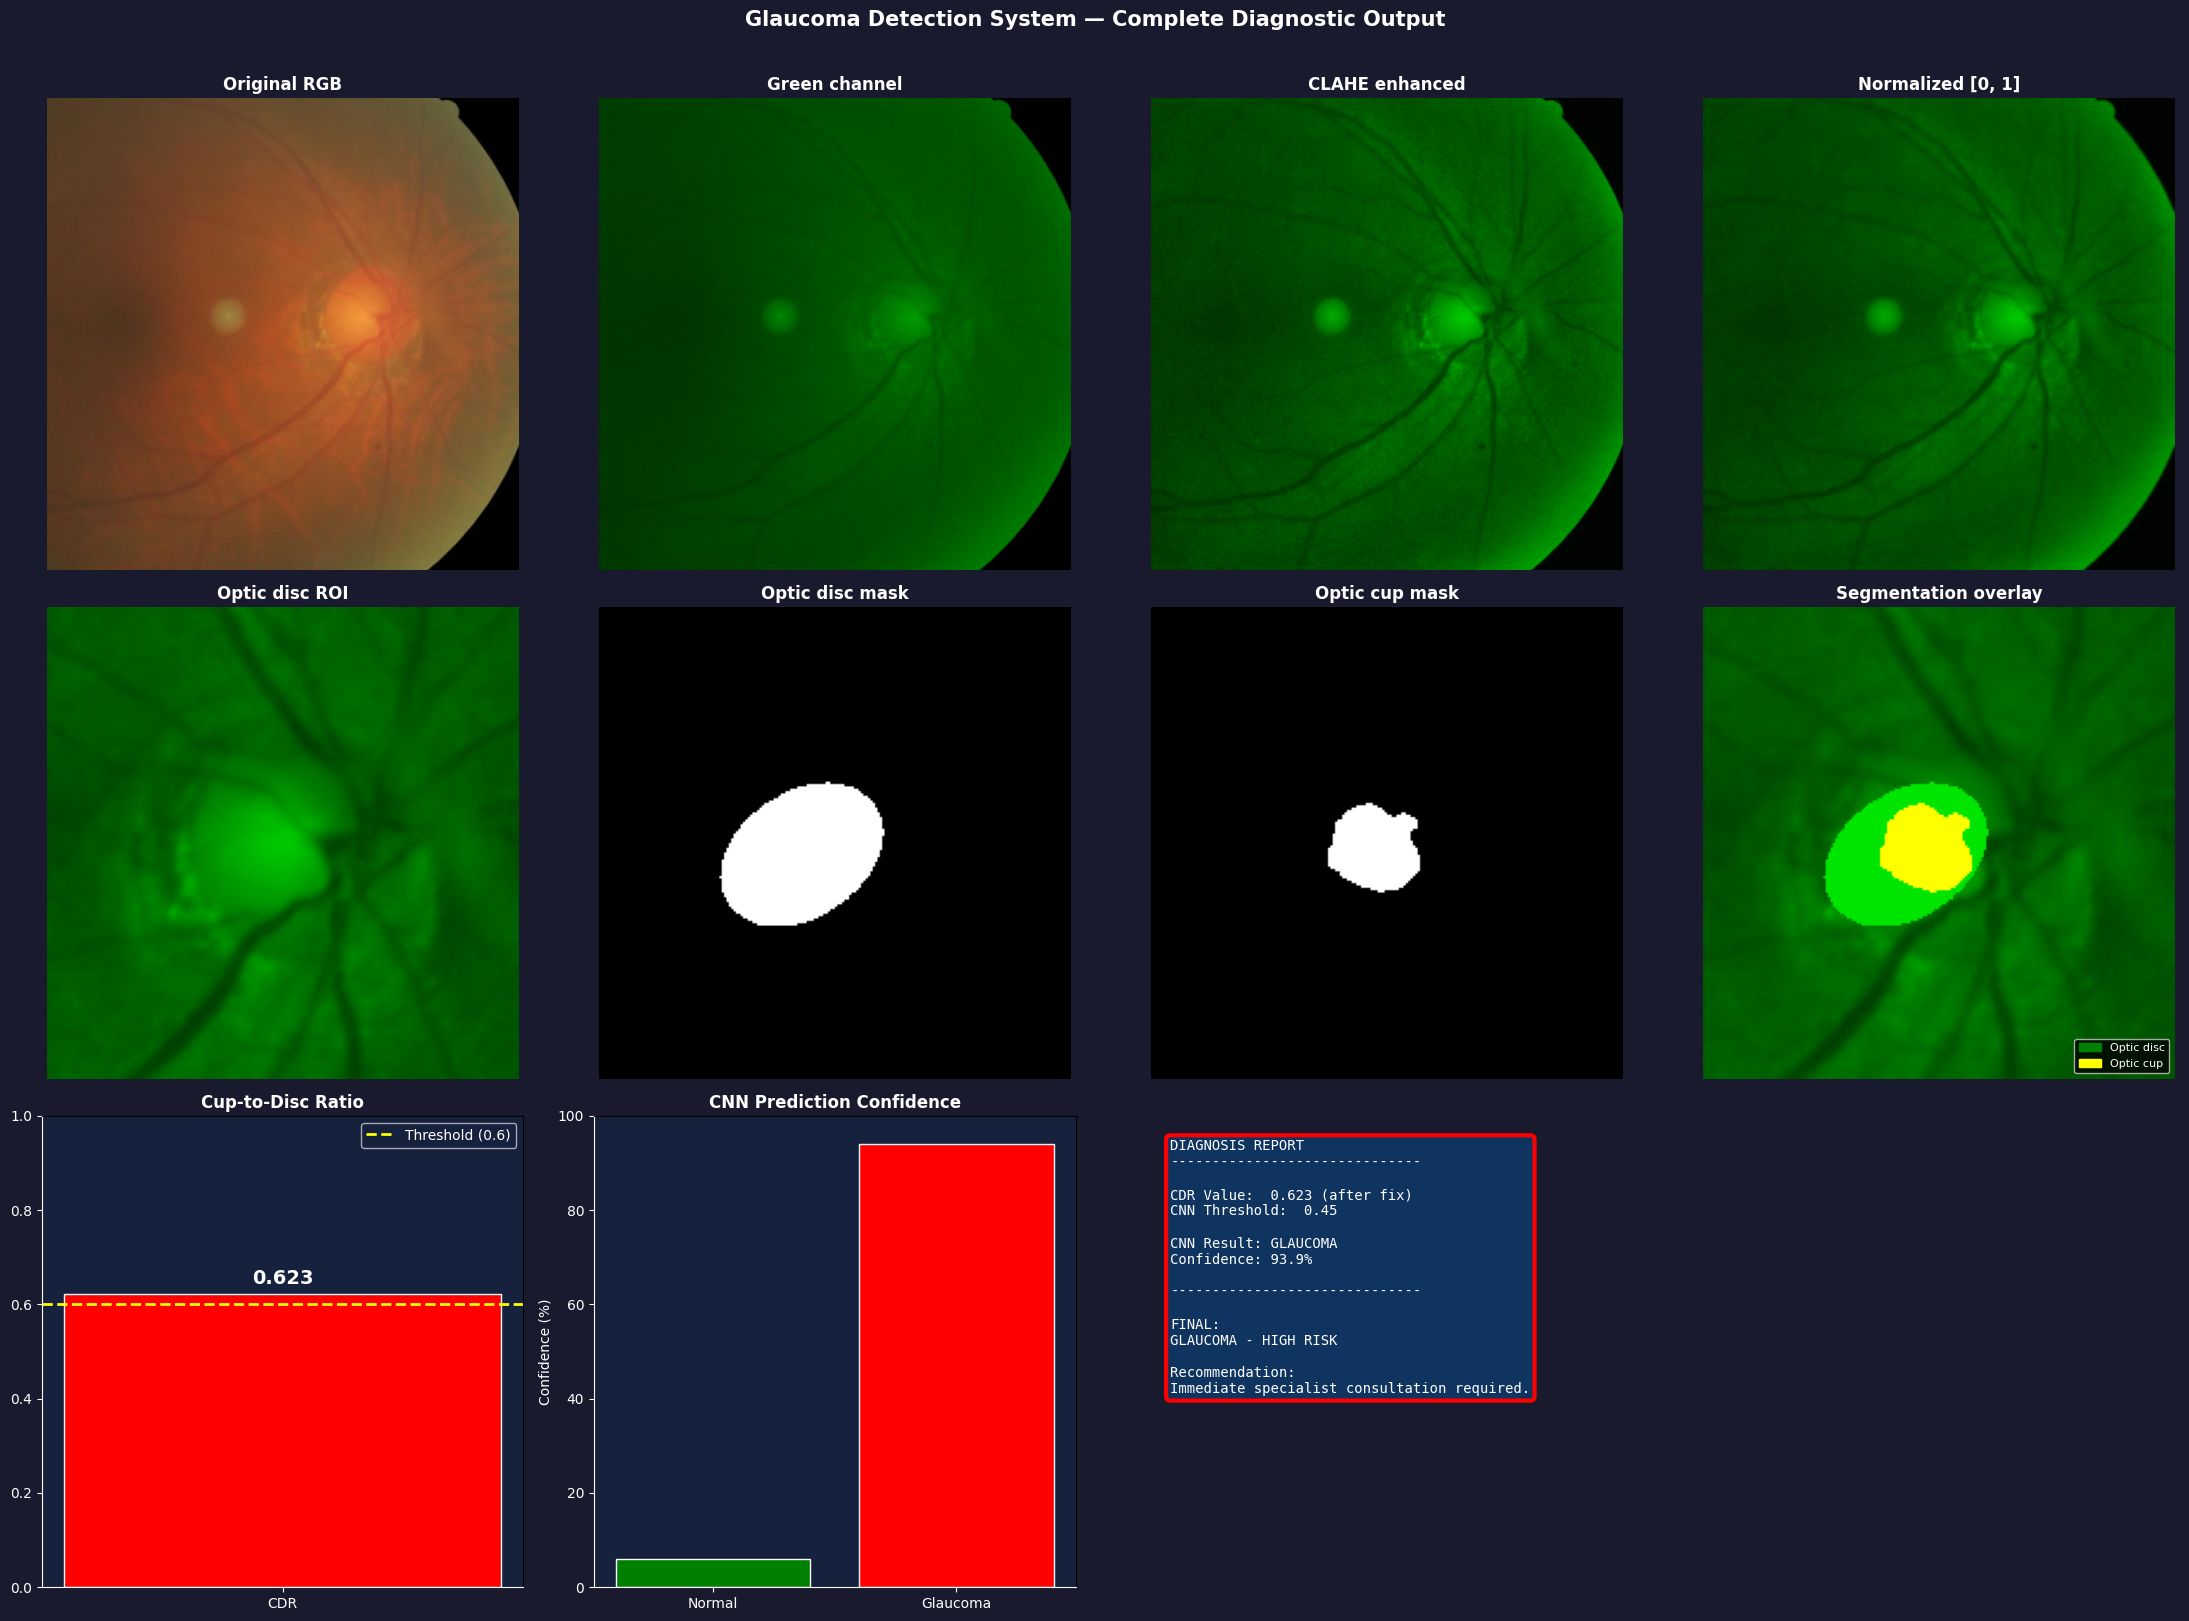

CDR: 0.6230
CNN: GLAUCOMA (93.9%)
Final: GLAUCOMA - HIGH RISK


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
from PIL import Image
from torchvision import transforms

project_root = Path(r"c:/Users/svmoo/OneDrive/Documents/GLAUCOMA/glaucoma_project")
sys.path.insert(0, str(project_root / "src"))

from cdr import compute_cdr, interpret_cdr
from model import create_resnet50_model
from preprocessing import find_first_image, preprocess_image
from segmentation import detect_optic_disc_roi, segment_disc_and_cup


def to_green(gray: np.ndarray) -> np.ndarray:
    """Convert grayscale or float images to green-tinted RGB for display."""
    if gray.dtype != np.uint8:
        img = np.clip(gray * 255.0, 0, 255).astype(np.uint8)
    else:
        img = gray.copy()
    rgb = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    rgb[:, :, 1] = img
    return rgb


predict_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

decision_threshold = 0.45

image_path = find_first_image(project_root / "dataset" / "test" / "glaucoma")
if image_path is None:
    image_path = find_first_image(project_root / "dataset" / "test" / "normal")
if image_path is None:
    raise FileNotFoundError("No test image found in dataset/test/glaucoma or dataset/test/normal.")

model_path = project_root / "outputs" / "models" / "best_model.pth"
device = torch.device("cpu")

print(f"Using image: {image_path.name}")
print(f"CNN decision threshold: {decision_threshold:.2f}")

model = create_resnet50_model()
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

prep_results = preprocess_image(str(image_path), use_clahe=True)
roi, center, bbox = detect_optic_disc_roi(prep_results["normalized"])
disc_mask, cup_mask, _, _ = segment_disc_and_cup(roi)

cup_mask_fixed = (cup_mask.astype(np.uint8) * disc_mask.astype(np.uint8)).astype(np.uint8)

image_pil = Image.open(image_path).convert("RGB")
image_tensor = torch.as_tensor(predict_transform(image_pil))
input_tensor = image_tensor.unsqueeze(0).to(device)
with torch.no_grad():
    probability = float(model(input_tensor).item())
cnn_pred = "GLAUCOMA" if probability >= decision_threshold else "NORMAL"
confidence = probability * 100.0 if cnn_pred == "GLAUCOMA" else (1 - probability) * 100.0

cdr, cdr_details = compute_cdr(disc_mask, cup_mask_fixed)
interpretation = interpret_cdr(cdr)
final = (
    {"label": "GLAUCOMA - HIGH RISK", "color": "red", "recommendation": "Immediate specialist consultation required."}
    if cdr >= 0.6 and cnn_pred == "GLAUCOMA"
    else {"label": "NORMAL", "color": "green", "recommendation": "Routine ophthalmological checkup (annual)."}
    if cdr < 0.6 and cnn_pred == "NORMAL"
    else {
        "label": "BORDERLINE - MANUAL REVIEW NEEDED",
        "color": "orange",
        "recommendation": (
            f"CDR suggests {'Glaucoma' if cdr >= 0.6 else 'Normal'} but CNN predicts {cnn_pred}. "
            f"Please consult an ophthalmologist."
        ),
    }
)

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
fig.patch.set_facecolor("#1a1a2e")
fig.suptitle("Glaucoma Detection System — Complete Diagnostic Output", fontsize=15, fontweight="bold", color="white", y=1.01)

axes[0, 0].imshow(prep_results["original_rgb"])
axes[0, 0].set_title("Original RGB", color="white", fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(to_green(prep_results["green_channel"]))
axes[0, 1].set_title("Green channel", color="white", fontweight="bold")
axes[0, 1].axis("off")

axes[0, 2].imshow(to_green(prep_results["clahe_enhanced"]))
axes[0, 2].set_title("CLAHE enhanced", color="white", fontweight="bold")
axes[0, 2].axis("off")

axes[0, 3].imshow(to_green(prep_results["normalized"]))
axes[0, 3].set_title("Normalized [0, 1]", color="white", fontweight="bold")
axes[0, 3].axis("off")

axes[1, 0].imshow(to_green(roi))
axes[1, 0].set_title("Optic disc ROI", color="white", fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(disc_mask * 255, cmap="gray", vmin=0, vmax=255)
axes[1, 1].set_title("Optic disc mask", color="white", fontweight="bold")
axes[1, 1].axis("off")

axes[1, 2].imshow(cup_mask_fixed * 255, cmap="gray", vmin=0, vmax=255)
axes[1, 2].set_title("Optic cup mask", color="white", fontweight="bold")
axes[1, 2].axis("off")

seg_overlay = np.zeros((*roi.shape, 3), dtype=np.float32)
seg_overlay[:, :, 1] = roi

disc_coords = np.where(disc_mask > 0)
cup_coords = np.where(cup_mask_fixed > 0)
seg_overlay[disc_coords[0], disc_coords[1]] = [0.0, 0.9, 0.0]
seg_overlay[cup_coords[0], cup_coords[1]] = [1.0, 1.0, 0.0]
axes[1, 3].imshow(np.clip(seg_overlay, 0, 1))
disc_patch = mpatches.Patch(color="green", label="Optic disc")
cup_patch = mpatches.Patch(color="yellow", label="Optic cup")
axes[1, 3].legend(handles=[disc_patch, cup_patch], loc="lower right", fontsize=8, facecolor="black", labelcolor="white")
axes[1, 3].set_title("Segmentation overlay", color="white", fontweight="bold")
axes[1, 3].axis("off")

ax5 = axes[2, 0]
ax5.bar(["CDR"], [cdr], color=("red" if cdr >= 0.6 else "green"), width=0.4, edgecolor="white")
ax5.axhline(y=0.6, color="yellow", linestyle="--", linewidth=2, label="Threshold (0.6)")
ax5.set_ylim(0, 1.0)
ax5.set_facecolor("#16213e")
ax5.tick_params(colors="white")
ax5.spines["bottom"].set_color("white")
ax5.spines["left"].set_color("white")
ax5.text(0, cdr + 0.02, f"{cdr:.3f}", ha="center", color="white", fontweight="bold", fontsize=14)
ax5.set_title("Cup-to-Disc Ratio", color="white", fontweight="bold")
ax5.legend(facecolor="#16213e", labelcolor="white")

ax6 = axes[2, 1]
normal_conf = (1 - probability) * 100.0
glaucoma_conf = probability * 100.0
ax6.bar(["Normal", "Glaucoma"], [normal_conf, glaucoma_conf], color=["green", "red"], edgecolor="white")
ax6.set_ylim(0, 100)
ax6.set_facecolor("#16213e")
ax6.tick_params(colors="white")
ax6.spines["bottom"].set_color("white")
ax6.spines["left"].set_color("white")
ax6.set_ylabel("Confidence (%)", color="white")
ax6.set_title("CNN Prediction Confidence", color="white", fontweight="bold")

axes[2, 2].axis("off")
axes[2, 3].axis("off")
report_txt = (
    "DIAGNOSIS REPORT\n"
    + ("-" * 30)
    + "\n\n"
    + f"CDR Value:  {cdr:.3f} (after fix)\n"
    + f"CNN Threshold:  {decision_threshold:.2f}\n\n"
    + f"CNN Result: {cnn_pred}\n"
    + f"Confidence: {confidence:.1f}%\n\n"
    + ("-" * 30)
    + "\n\n"
    + f"FINAL DIAGNOSIS:\n{final['label']}\n\n"
    + f"Recommendation:\n{final['recommendation']}"
)
axes[2, 2].text(
    0.05,
    0.95,
    report_txt,
    transform=axes[2, 2].transAxes,
    fontsize=10,
    verticalalignment="top",
    fontfamily="monospace",
    color="white",
    bbox=dict(boxstyle="round", facecolor="#0f3460", edgecolor=final["color"], linewidth=3),
)

plt.tight_layout()
plt.show()

print(f"CDR: {cdr:.4f}")
print(f"CNN: {cnn_pred} ({confidence:.1f}%)")
print(f"Final diagnosis: {final['label']}")
print(f"Recommendation: {final['recommendation']}")

In [ ]:
from pathlib import Path
import json

project_root = Path(r"c:/Users/svmoo/OneDrive/Documents/GLAUCOMA/glaucoma_project")
recall_path = project_root / "outputs" / "results" / "tuned_recall_summary.json"
balanced_path = project_root / "outputs" / "results" / "tuned_balanced_summary.json"
baseline_summary_path = project_root / "outputs" / "results" / "resnet_summary.json"

def load_summary(summary_path):
    if not summary_path.exists():
        return None
    with summary_path.open("r", encoding="utf-8") as handle:
        return json.load(handle)

recall_summary = load_summary(recall_path)
balanced_summary = load_summary(balanced_path)

if recall_summary and balanced_summary:
    recall_metrics = recall_summary["test_metrics"]
    recall_tuning = recall_summary["tuning"]
    balanced_metrics = balanced_summary["test_metrics"]
    balanced_tuning = balanced_summary["tuning"]

    print("TUNED RESULTS COMPARISON")
    print("-" * 40)
    print("Recall-first")
    print(f"  Threshold: {recall_tuning['threshold']:.4f}")
    print(f"  Accuracy:  {recall_metrics['accuracy'] * 100:.2f}%")
    print(f"  Precision: {recall_metrics['precision'] * 100:.2f}%")
    print(f"  Recall:    {recall_metrics['recall'] * 100:.2f}%")
    print(f"  F1 Score:  {recall_metrics['f1'] * 100:.2f}%")
    print()
    print("Balanced")
    print(f"  Threshold: {balanced_tuning['threshold']:.4f}")
    print(f"  Accuracy:  {balanced_metrics['accuracy'] * 100:.2f}%")
    print(f"  Precision: {balanced_metrics['precision'] * 100:.2f}%")
    print(f"  Recall:    {balanced_metrics['recall'] * 100:.2f}%")
    print(f"  F1 Score:  {balanced_metrics['f1'] * 100:.2f}%")
    print()
    print("Recommendation: use Balanced for deployment metrics, use Recall-first for screening safety review.")
elif recall_summary:
    recall_metrics = recall_summary["test_metrics"]
    recall_tuning = recall_summary["tuning"]
    print("TUNED EVALUATION SUMMARY")
    print("-" * 40)
    print(f"Threshold:   {recall_tuning['threshold']:.4f}")
    print(f"Accuracy:    {recall_metrics['accuracy'] * 100:.2f}%")
    print(f"Precision:   {recall_metrics['precision'] * 100:.2f}%")
    print(f"Recall:      {recall_metrics['recall'] * 100:.2f}%")
    print(f"F1 Score:    {recall_metrics['f1'] * 100:.2f}%")
    print(f"ROC-AUC:     {recall_metrics['roc_auc']:.4f}")
elif baseline_summary_path.exists():
    with baseline_summary_path.open("r", encoding="utf-8") as handle:
        summary = json.load(handle)
    metrics = summary["performance_metrics"]
    confusion = metrics["confusion_matrix"]
    print("BASELINE SUMMARY")
    print("-" * 40)
    print(f"Accuracy:    {metrics['accuracy'] * 100:.2f}%")
    print(f"Precision:   {metrics['precision'] * 100:.2f}%")
    print(f"Recall:      {metrics['recall'] * 100:.2f}%")
    print(f"F1 Score:    {metrics['f1'] * 100:.2f}%")
    print(f"Specificity: {metrics['specificity'] * 100:.2f}%")
    print()
    print(f"TP: {confusion['TP']} | TN: {confusion['TN']} | FP: {confusion['FP']} | FN: {confusion['FN']}")
    print(f"Mean probability: {summary['mean_probability']:.4f}")
    print(f"High confidence images: {summary['high_confidence_count']}")

TUNED RESULTS COMPARISON
----------------------------------------
Recall-first
  Threshold: 0.2487
  Accuracy:  81.82%
  Precision: 68.61%
  Recall:    95.08%
  F1 Score:  79.70%

Balanced
  Threshold: 0.4742
  Accuracy:  89.28%
  Precision: 87.73%
  Recall:    83.07%
  F1 Score:  85.34%

Recommendation: use Balanced for deployment metrics, use Recall-first for screening safety review.
